<a href="https://colab.research.google.com/github/ayaz-ali-36/Machine-Learning/blob/main/Handling%20Imbalance%20Data/Lab_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings('ignore')

In [22]:
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)
print(df.shape)

# take sample because dataset is huge
df = df.sample(n=20000, random_state=42)

print(df.shape)

print(df['Class'].value_counts())
print(df['Class'].mean()*100)


(284807, 31)
(20000, 31)
Class
0    19966
1       34
Name: count, dtype: int64
0.16999999999999998


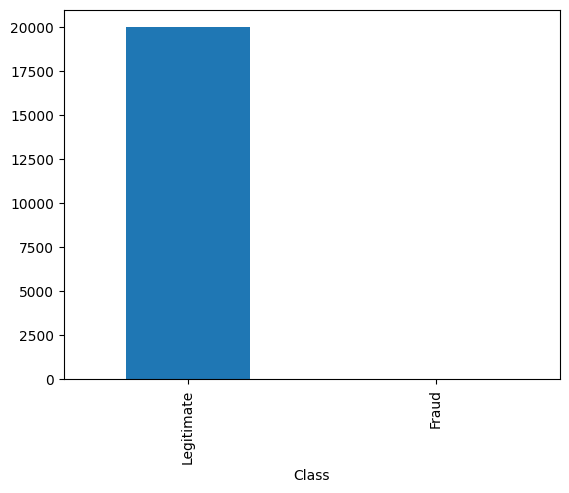

In [23]:
df['Class'].value_counts().plot(kind='bar')
plt.xticks([0, 1],
           ['Legitimate', 'Fraud'])
plt.show()


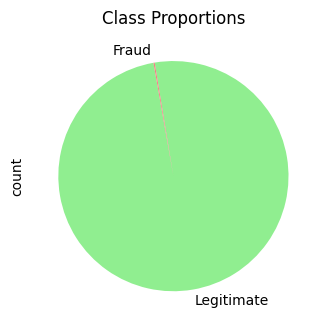

In [24]:
plt.subplot(1, 2, 2)
df['Class'].value_counts().plot(
    kind='pie',
    labels=['Legitimate', 'Fraud'],
    colors=['lightgreen', 'lightcoral'],

    startangle=100
)
plt.title('Class Proportions')

plt.tight_layout()
plt.show()

In [25]:
X = df.drop('Class', axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)

X_test_sc = scaler.transform(X_test)

Baselin Model

In [27]:
baseline_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

baseline_model.fit(X_train_sc, y_train)

y_pred_base = baseline_model.predict(X_test_sc)


In [28]:
print(classification_report(
    y_test, y_pred_base,
    target_names=['Legitimate', 'Fraud']
))
print(f"F2 Score (recall-weighted): "
      f"{fbeta_score(y_test, y_pred_base, beta=2):.3f}")

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      3993
       Fraud       0.75      0.43      0.55         7

    accuracy                           1.00      4000
   macro avg       0.87      0.71      0.77      4000
weighted avg       1.00      1.00      1.00      4000

F2 Score (recall-weighted): 0.469


In this step we use -Class Weights

In [29]:
cw_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)
cw_model.fit(X_train_sc, y_train)
y_pred_cw = cw_model.predict(X_test_sc)
print(classification_report(
    y_test, y_pred_cw,
    target_names=['Legitimate', 'Fraud']
))
print(f"F2 Score: "
      f"{fbeta_score(y_test, y_pred_cw, beta=2):.3f}")

              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00      3993
       Fraud       0.10      0.57      0.17         7

    accuracy                           0.99      4000
   macro avg       0.55      0.78      0.58      4000
weighted avg       1.00      0.99      0.99      4000

F2 Score: 0.294


In this stepwe use Smote(oversampling)

In [42]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = \
    smote.fit_resample(X_train_sc, y_train)
smote_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)
smote_model.fit(X_train_smote, y_train_smote)
y_pred_smote = smote_model.predict(X_test_sc)

print(classification_report(
    y_test, y_pred_smote,
    target_names=['Legitimate', 'Fraud']
))
print(f"F2 Score: "
      f"{fbeta_score(y_test, y_pred_smote, beta=2):.3f}")

              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00      3993
       Fraud       0.11      0.57      0.18         7

    accuracy                           0.99      4000
   macro avg       0.55      0.78      0.59      4000
weighted avg       1.00      0.99      0.99      4000

F2 Score: 0.303


Smote + Oversampling

In [40]:
smt = SMOTETomek(random_state=42)
X_train_smt, y_train_smt = \
    smt.fit_resample(X_train_sc, y_train)
smt_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)
smt_model.fit(X_train_smt, y_train_smt)
y_pred_smt = smt_model.predict(X_test_sc)

print(classification_report(
    y_test, y_pred_smt,
    target_names=['Legitimate', 'Fraud']
))
print(f"F2 Score: "
      f"{fbeta_score(y_test, y_pred_smt, beta=2):.3f}")

              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00      3993
       Fraud       0.11      0.57      0.18         7

    accuracy                           0.99      4000
   macro avg       0.55      0.78      0.59      4000
weighted avg       1.00      0.99      0.99      4000

F2 Score: 0.303


Now Threshold Adjustment

In [33]:


# Get fraud probabilities
y_prob = baseline_model.predict_proba(X_test_sc)[:, 1]

# Different thresholds
thresholds = [0.1,0.2, 0.3,0.4, 0.5]

print("Threshold  Precision  Recall")

for t in thresholds:

    # Convert probabilities into predictions
    y_pred = (y_prob >= t).astype(int)

    # Calculate metrics
    p = precision_score(y_test, y_pred)
    r = recall_score(y_test, y_pred)

    # Print results
    print(f"{t}        {p:.2f}       {r:.2f}")

Threshold  Precision  Recall
0.1        0.80       0.57
0.2        0.80       0.57
0.3        0.80       0.57
0.4        0.75       0.43
0.5        0.75       0.43


Cross Validation

In [37]:
model_cv = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

# Normal KFold
kf = KFold(n_splits=5)

scores_kf = cross_val_score(
    model_cv,
    X_train_sc,
    y_train,
    cv=kf,
    scoring='f1'
)
# Stratified KFold
skf = StratifiedKFold(n_splits=5)

scores_skf = cross_val_score(
    model_cv,
    X_train_sc,
    y_train,
    cv=skf,
    scoring='f1'
)

print("KFold Mean:", scores_kf.mean())
print("Stratified Mean:", scores_skf.mean())

KFold Mean: 0.27188239259667835
Stratified Mean: 0.2744725311762723



FINAL COMPARISON

Baseline
Precision: 0.75
Recall:    0.43
F1 Score:  0.55
F2 Score:  0.47
------------------------------
Class Weight
Precision: 0.1
Recall:    0.57
F1 Score:  0.17
F2 Score:  0.29
------------------------------
SMOTE
Precision: 0.11
Recall:    0.57
F1 Score:  0.18
F2 Score:  0.3
------------------------------
SMOTETomek
Precision: 0.11
Recall:    0.57
F1 Score:  0.18
F2 Score:  0.3
------------------------------


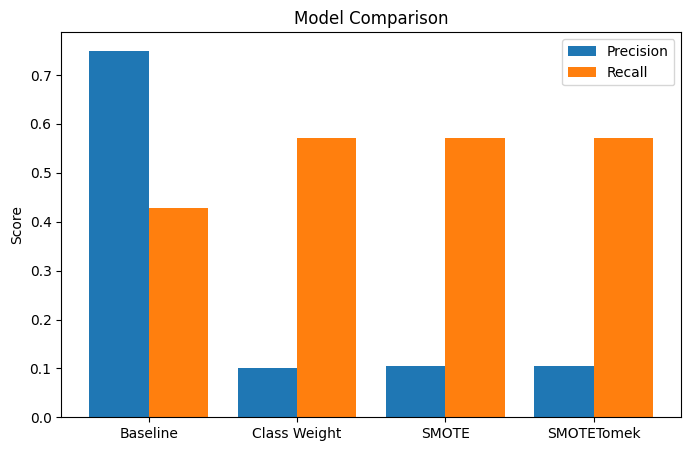

In [43]:
print("\nFINAL COMPARISON\n")

strategies = {
    "Baseline": y_pred_base,
    "Class Weight": y_pred_cw,
    "SMOTE": y_pred_smote,
    "SMOTETomek": y_pred_smt
}

for name, preds in strategies.items():

    p = precision_score(y_test, preds)
    r = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    f2 = fbeta_score(y_test, preds, beta=2)

    print(name)
    print("Precision:", round(p, 2))
    print("Recall:   ", round(r, 2))
    print("F1 Score: ", round(f1, 2))
    print("F2 Score: ", round(f2, 2))
    print("-" * 30)

# Graph

names = list(strategies.keys())

precision_scores = [
    precision_score(y_test, p)
    for p in strategies.values()
]

recall_scores = [
    recall_score(y_test, p)
    for p in strategies.values()
]

plt.figure(figsize=(8,5))

x = np.arange(len(names))

plt.bar(x - 0.2, precision_scores,
        width=0.4,
        label="Precision")

plt.bar(x + 0.2, recall_scores,
        width=0.4,
        label="Recall")

plt.xticks(x, names)
plt.ylabel("Score")
plt.title("Model Comparison")
plt.legend()

plt.show()